# 05 - Thermal Comfort (UTCI): v1 vs `physics:"advanced"`

**What it computes.** The Universal Thermal Climate Index - the felt ("real-
feel") outdoor temperature combining air temperature, humidity, wind and mean
radiant temperature (sun, sky and surface radiation). Output is a 512x512
grid of degC. This is the headline pedestrian-comfort metric.

**Advanced inputs gained.** Thermal models do **not** take the surface-sensor
fields - they run the terrain-aware **grid** path only. What UTCI gains:

* `physics`: `"v1"` (default) | `"detail"` | `"advanced"`.
  * **v1** - absolute per-cell UTCI (Broede polynomial on a coarse-grid MRT).
  * **advanced** - hourly time-stepping, SOLWEIG-form surface-temperature
    phase lag, UTCI evaluated *every hour then averaged* (UTCI is nonlinear in
    MRT), with the **canopy ray-march on by default**.
* `canopy-transmissivity` (global psi, [0,1], default 0.40) - shortwave
  transmissivity for the advanced canopy ray-march; per-tree override via
  `transmissivity` on each `vegetation` entry.
* `ground-geometry` - terrain drape (accepted on thermal models).
* forward **multi-month / annual** `time-period`.

**When to use.** `advanced` when you care about canopy shade, surface-
temperature lag and realistic MRT (the things that move comfort by several
degrees); v1 for a fast first pass.

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city


buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


In [2]:
# Weather: nearest TMY file to the AOI, filtered to the analysis window.
from infrared_sdk.models import TimePeriod, Location

weather_id = ia.fetch_weather_identifier(client)
print("weather file:", weather_id)

weather file: AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023


## Build the UTCI body (full weather array set)

UTCI needs the full weather set: horizontal-infrared, DHI, DNI, GHI, dry-bulb,
relative humidity and wind speed. The SDK's `from_weatherfile_payload`
assembles them; we then add geometry, vegetation and ground materials.

In [3]:
from infrared_sdk.analyses.types import UtciModelRequest, AnalysesName

# Vegetation + ground materials sharpen the advanced canopy / surface physics.
vegetation = ia.fetch_vegetation(client, ia.VIENNA_KARLSPLATZ, "karlsplatz_veg.json")
ground = ia.fetch_ground_materials(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_ground.json"
)
print(f"vegetation features: {len(vegetation)} | ground layers: {list(ground)}")

# Hot summer afternoon - where advanced physics diverges most from v1.
tp = TimePeriod(
    start_month=7, start_day=15, start_hour=12, end_month=7, end_day=15, end_hour=16
)
loc = Location(latitude=ia.VIENNA_LAT, longitude=ia.VIENNA_LON)
wp = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)


def utci_body(extra=None):
    b = UtciModelRequest.from_weatherfile_payload(
        UtciModelRequest(
            analysis_type=AnalysesName.thermal_comfort_index,
            latitude=ia.VIENNA_LAT,
            longitude=ia.VIENNA_LON,
            time_period=tp,
        ),
        loc,
        tp,
        wp,
    ).to_dict()
    b["latitude"] = ia.VIENNA_LAT
    b["longitude"] = ia.VIENNA_LON
    b["geometries"] = buildings
    if vegetation:
        b["vegetation"] = vegetation
    if ground:
        b["ground-materials"] = ground
    if extra:
        b.update(extra)
    return b

vegetation features: 705 | ground layers: ['asphalt', 'building', 'concrete', 'vegetation', 'soil', 'water']


## Standard run - `physics:"v1"` (default)

No `physics` field = v1. Returns the standard thermal grid (`output`,
512x512 degC).

[thermal-comfort-index/v1] Succeeded in 2.1s  keys=['max-legend', 'min-legend', 'output']
v1 grid: (512, 512) | mean UTCI: 30.62 degC


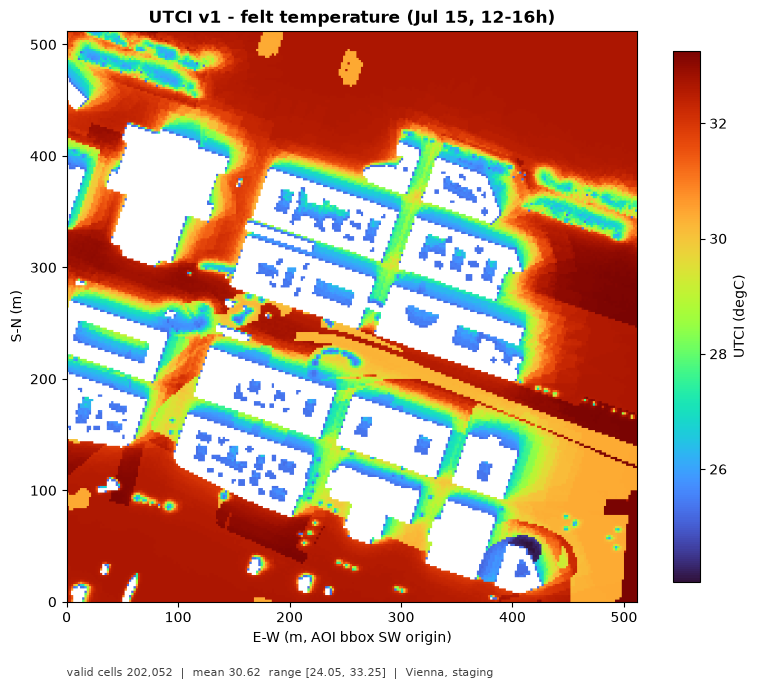

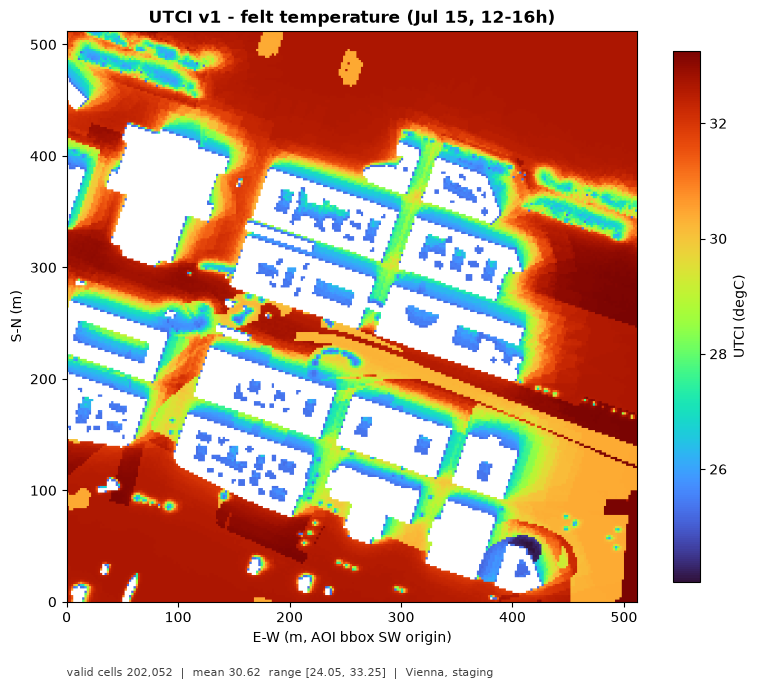

In [4]:
v1_res, info = ia.run_job("thermal-comfort-index", utci_body(), label="v1")
v1 = np.array(v1_res["output"], dtype=float)
print("v1 grid:", v1.shape, "| mean UTCI: %.2f degC" % float(np.nanmean(v1)))
fig, ax = ir.grid_heatmap(
    v1,
    title="UTCI v1 - felt temperature (Jul 15, 12-16h)",
    cbar_label="UTCI (degC)",
    cmap="turbo",
    crop=True,
    note="Vienna, staging",
)
fig

## Advanced run - `physics:"advanced"`

Add `physics:"advanced"` (and optionally `canopy-transmissivity`). Same grid
shape, but hourly-stepped with canopy ray-march and surface-temperature lag.

[thermal-comfort-index/advanced] Succeeded in 1.5s  keys=['max-legend', 'min-legend', 'output']
advanced grid: (512, 512) | mean UTCI: 30.93 degC


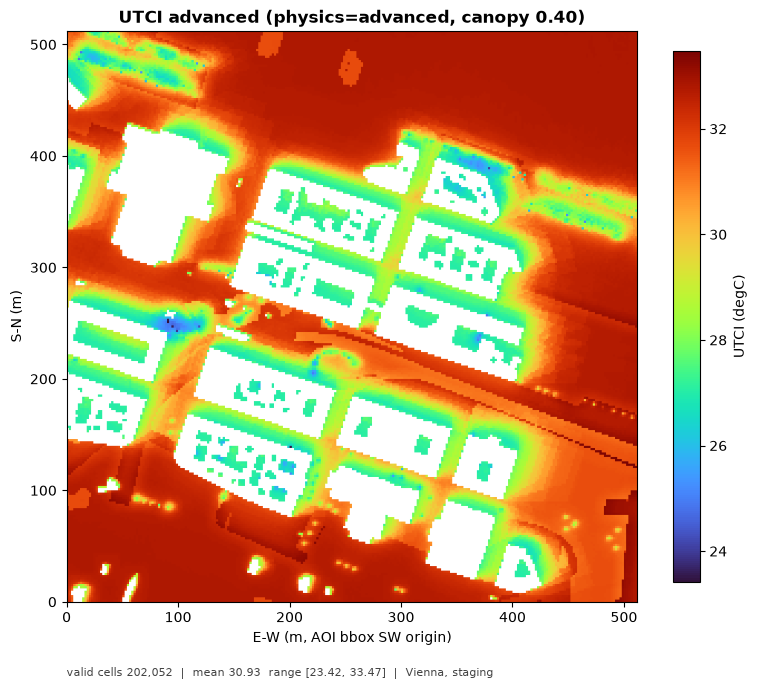

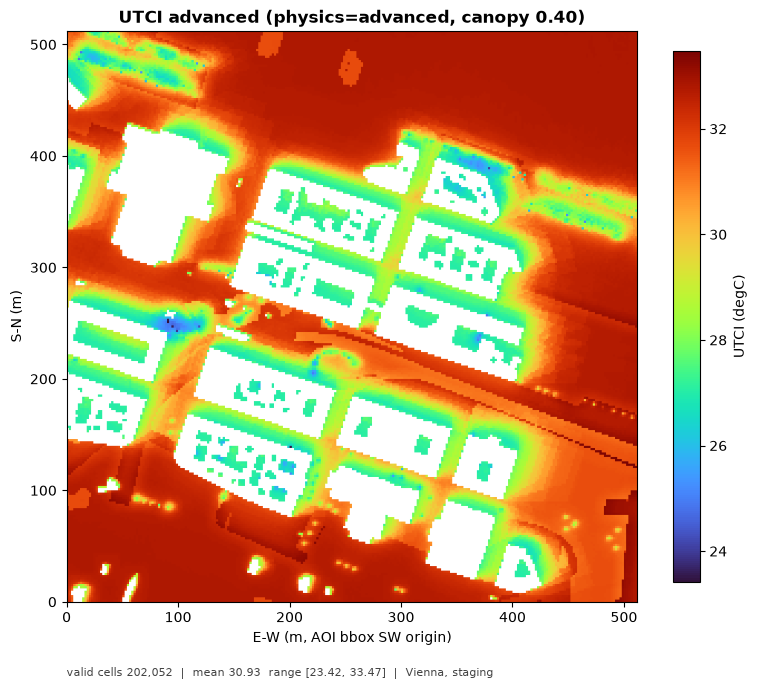

In [5]:
adv_res, info = ia.run_job(
    "thermal-comfort-index",
    utci_body(extra={"physics": "advanced", "canopy-transmissivity": 0.40}),
    label="advanced",
)
adv = np.array(adv_res["output"], dtype=float)
print("advanced grid:", adv.shape, "| mean UTCI: %.2f degC" % float(np.nanmean(adv)))
fig, ax = ir.grid_heatmap(
    adv,
    title="UTCI advanced (physics=advanced, canopy 0.40)",
    cbar_label="UTCI (degC)",
    cmap="turbo",
    crop=True,
    note="Vienna, staging",
)
fig

### Result payload, described

UTCI uses the **standard grid** shape (not surfaces):

```json
{ "output": [[...512...], ... 512 rows ...],   // null = no-data cell, degC
  "min-legend": <num|null>, "max-legend": <num|null> }
```

* **`output`** - 512x512 row-major grid of felt temperature in degC; `null`
  outside the data mask. Read it like any grid result (`np.array(...)`).
* **`min-legend` / `max-legend`** - suggested colorbar bounds (often `null`;
  compute your own from the finite values).

`advanced` is grid-shaped identically to v1, so the **delta** below is a clean
per-cell subtraction.

In [6]:
import json

print("result keys:", sorted(adv_res))
print("legend:", adv_res.get("min-legend"), "->", adv_res.get("max-legend"))
print(
    "sample row 256, cols 250-256:",
    json.dumps(
        [None if not np.isfinite(x) else round(float(x), 2) for x in adv[256, 250:256]]
    ),
)

result keys: ['max-legend', 'min-legend', 'output']
legend: 23 -> 33
sample row 256, cols 250-256: [null, null, null, null, null, null]


## The money shot - advanced minus v1

Where does advanced physics change the felt temperature? Canopy shade and
surface-temperature lag can shift individual cells by several degrees even when
the mean barely moves.

v1 -> advanced:  mean dUTCI = +0.30 degC | mean|d| = 0.54 | max|d| = 4.20 (over 202052 cells)


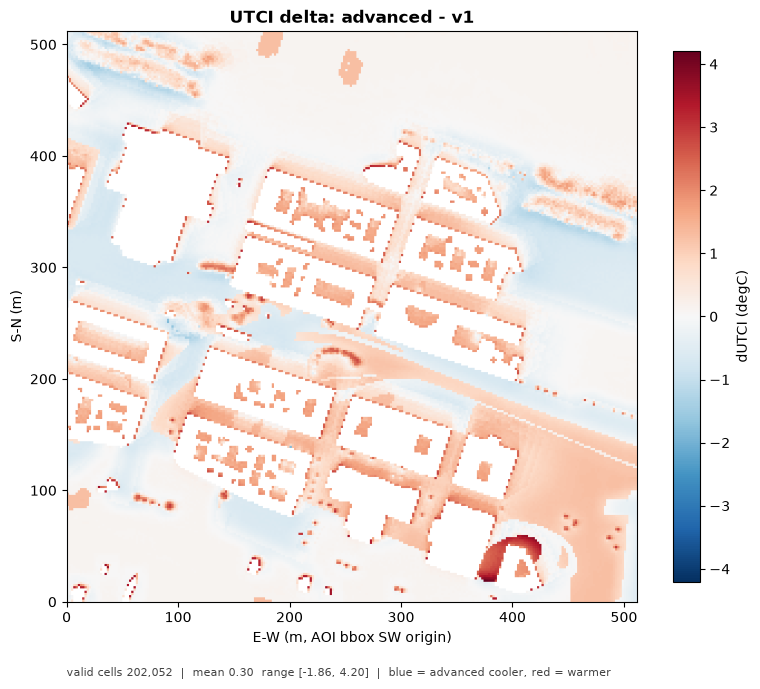

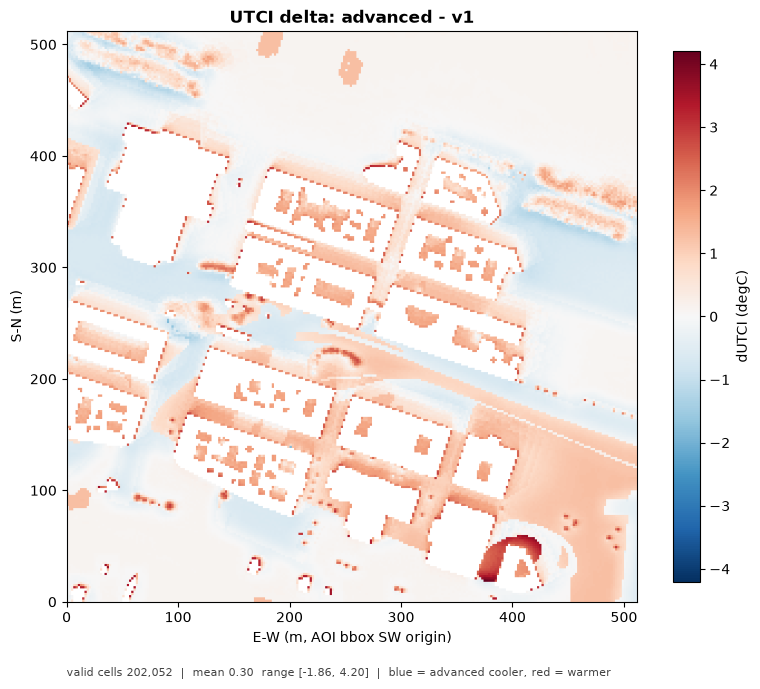

In [7]:
delta = adv - v1
d = delta[np.isfinite(delta)]
print(
    "v1 -> advanced:  mean dUTCI = %+.2f degC | mean|d| = %.2f | max|d| = %.2f (over %d cells)"
    % (
        float(np.nanmean(d)),
        float(np.nanmean(np.abs(d))),
        float(np.nanmax(np.abs(d))),
        d.size,
    )
)
fig, ax = ir.grid_heatmap(
    delta,
    title="UTCI delta: advanced - v1",
    cbar_label="dUTCI (degC)",
    cmap="RdBu_r",
    diverging=True,
    crop=True,
    note="blue = advanced cooler, red = warmer",
)
fig

## Notes

* Thermal models reject the surface-sensor fields (`analysis-surfaces`,
  `sensor-points`, `context-geometry`) with HTTP 400 - they cover the
  grid + `ground-geometry` path only (see notebook `06` for terrain).
* Forward multi-month / annual windows work on UTCI too (advanced uses
  representative-day clustering). Widen `tp` to e.g. Jun-Aug for a seasonal
  comfort grid.
* `context-geometry` on advanced/detail UTCI just merged (PR #119) but is
  **not live** until the next staging re-deploy - until then use `physics:"v1"`
  if you need context occlusion on a thermal run (see notebook `07`).